# MVP v0.2.5.12: D4RL Diagnostics (Quick) — Cross vs Within

**Date:** 2026-03-17
**Builds on:** v0.2.5.10, hopper_d4rl_diagnostics.md

Quick run: just the 6 diagnostics from hopper_d4rl_diagnostics.md on our cross/within
BC_Gaussian policies. No guided generation or OPE metrics (those are in v0.2.5.11).

**Diagnostics:**
1. Pairwise cosine similarity of scorer gradients
2. |grad|/|action| ratio
3. Gradient direction test (GD convergence)
4. Per-dimension trajectory RMSE (unguided, short T_gen=200)
5. Action NLL under target policies
6. Trajectory plots

**Reference:** SOPE 11 SAC policies: cos=0.47, |grad|/|act|=573, GD=-26%, NLL spread=39.9

In [1]:
%matplotlib inline
import sys, os, math, time, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import wasserstein_distance

warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["D4RL_SUPPRESS_IMPORT_ERROR"] = "1"

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

import gym
import d4rl
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import apply_conditioning

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

HOPPER_OBS_DIM = 11
HOPPER_ACT_DIM = 3
BC_HIDDEN = [256, 256]
BC_LR = 1e-4
BC_BATCH = 256
BC_EPOCHS = 100
SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "d4rl_bc_gaussian"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims=[256, 256],
                 init_std=0.3, min_std=0.01, max_std=7.5):
        super().__init__()
        self.obs_dim, self.action_dim = obs_dim, action_dim
        self.min_std, self.max_std = min_std, max_std
        layers = []
        in_dim = obs_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(in_dim, action_dim)
        self.log_std_head = nn.Linear(in_dim, action_dim)
        nn.init.constant_(self.log_std_head.bias, np.log(np.exp(init_std) - 1.0))
        nn.init.zeros_(self.log_std_head.weight)

    def forward(self, obs):
        h = self.backbone(obs)
        return self.mean_head(h), torch.clamp(F.softplus(self.log_std_head(h)), self.min_std, self.max_std)

    def log_prob(self, obs, action):
        m, s = self.forward(obs)
        return torch.distributions.Normal(m, s).log_prob(action).sum(-1)

    @torch.no_grad()
    def grad_log_prob(self, obs, action):
        m, s = self.forward(obs)
        return -(action - m) / (s ** 2)

    @torch.no_grad()
    def sample_actions(self, obs):
        m, s = self.forward(obs)
        return m + s * torch.randn_like(m)

    def train_on_data(self, obs, actions, n_epochs, batch_size=256, lr=1e-4):
        opt = torch.optim.Adam(self.parameters(), lr=lr)
        dev = next(self.parameters()).device
        obs_t = torch.tensor(obs, dtype=torch.float32, device=dev)
        act_t = torch.tensor(actions, dtype=torch.float32, device=dev)
        N = len(obs_t)
        spe = max(1, N // batch_size)
        self.train()
        for ep in range(n_epochs):
            perm = torch.randperm(N, device=dev)
            for step in range(spe):
                idx = perm[step*batch_size:(step+1)*batch_size]
                if len(idx) == 0: continue
                nll = -self.log_prob(obs_t[idx], act_t[idx]).mean()
                opt.zero_grad(); nll.backward(); opt.step()
        self.eval()
        return -self.log_prob(obs_t[:1000], act_t[:1000]).mean().item()

print("Setup complete")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group


<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


pybullet build time: Jan 29 2025 23:16:28


Device: cuda
Setup complete


In [2]:
# ── Load data + train or load policies ──
CROSS_ENVS = [
    "hopper-random-v2", "hopper-medium-v2", "hopper-medium-replay-v2",
    "hopper-medium-expert-v2", "hopper-expert-v2", "hopper-full-replay-v2",
]
WITHIN_SIZES = [500, 1000, 5000, 10000, 50000, 100000]

cross_data = {}
print("Loading cross-dataset D4RL data...")
for env_name in CROSS_ENVS:
    env = gym.make(env_name)
    dataset = d4rl.qlearning_dataset(env)
    short = env_name.replace("hopper-", "").replace("-v2", "")
    cross_data[short] = {"obs": dataset["observations"].astype(np.float32),
                          "actions": dataset["actions"].astype(np.float32)}
    print(f"  {short:<20} {len(cross_data[short]['obs']):>8} transitions")
    env.close()

within_data = {}
rng = np.random.RandomState(42)
medium_obs, medium_act = cross_data["medium"]["obs"], cross_data["medium"]["actions"]
print("\nWithin-dataset subsets:")
for size in WITHIN_SIZES:
    name = f"med_{size//1000}k" if size >= 1000 else f"med_{size}"
    idx = rng.permutation(len(medium_obs))[:size]
    within_data[name] = {"obs": medium_obs[idx], "actions": medium_act[idx]}
    print(f"  {name:<20} {size:>8} transitions")

cross_names = list(cross_data.keys())
within_names = list(within_data.keys())

# Try loading saved weights from v0.2.5.11, train if not found
all_policies = {}
all_data = {**cross_data, **within_data}
prefixes = {n: "cross" for n in cross_names} | {n: "within" for n in within_names}

print(f"\nLoading/training policies...")
for name in cross_names + within_names:
    save_path = SAVE_DIR / f"{prefixes[name]}_{name}.pt"
    if save_path.exists():
        ckpt = torch.load(save_path, map_location=device)
        pol = GaussianPolicy(HOPPER_OBS_DIM, HOPPER_ACT_DIM, hidden_dims=BC_HIDDEN).to(device)
        pol.load_state_dict(ckpt["state_dict"])
        pol.eval()
        all_policies[name] = pol
        print(f"  {name:<20} loaded from disk (NLL={ckpt.get('nll', '?')})")
    else:
        data = all_data[name]
        print(f"  {name:<20} training...", end=" ", flush=True)
        t0 = time.time()
        pol = GaussianPolicy(HOPPER_OBS_DIM, HOPPER_ACT_DIM, hidden_dims=BC_HIDDEN).to(device)
        nll = pol.train_on_data(data["obs"], data["actions"], n_epochs=BC_EPOCHS, batch_size=BC_BATCH, lr=BC_LR)
        all_policies[name] = pol
        print(f"NLL={nll:.3f}, {time.time()-t0:.0f}s")
        torch.save({"state_dict": pol.state_dict(), "obs_dim": HOPPER_OBS_DIM, "act_dim": HOPPER_ACT_DIM,
                     "hidden_dims": BC_HIDDEN, "name": name, "nll": nll}, save_path)

# Common test data
test_obs_t = torch.tensor(medium_obs[:500], dtype=torch.float32, device=device)
test_act_t = torch.tensor(medium_act[:500], dtype=torch.float32, device=device)
print(f"\nAll {len(all_policies)} policies ready. Test batch: {test_obs_t.shape}")

/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Loading cross-dataset D4RL data...


load datafile:   0%|          | 0/9 [00:00<?, ?it/s]

load datafile:  11%|█         | 1/9 [00:00<00:01,  6.27it/s]

load datafile:  33%|███▎      | 3/9 [00:00<00:00,  6.14it/s]

...

  med_1k               loaded from disk (NLL=1.6755192279815674)


  med_5k               loaded from disk (NLL=0.6071904301643372)


  med_10k              loaded from disk (NLL=0.4200951159000397)


  med_50k              loaded from disk (NLL=-0.25318485498428345)


  med_100k             loaded from disk (NLL=-0.5080973505973816)

All 12 policies ready. Test batch: torch.Size([500, 11])


In [3]:
# ── Diagnostic 1: Pairwise Cosine Similarity ──
def run_diag1(policy_names, policies, test_obs, test_act, label):
    n = len(policy_names)
    grads = {nm: policies[nm].grad_log_prob(test_obs, test_act).cpu() for nm in policy_names}
    cos_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cos_mat[i, j] = F.cosine_similarity(grads[policy_names[i]], grads[policy_names[j]], dim=-1).mean().item()
    off = [cos_mat[i, j] for i in range(n) for j in range(i+1, n)]
    
    print(f"\n{'='*60}")
    print(f"Diag 1: Cosine Similarity — {label}")
    print(f"{'='*60}")
    short = [nm[:10] for nm in policy_names]
    print(f"   {'':>10}", end="")
    for s in short: print(f" {s:>10}", end="")
    print()
    for i in range(n):
        print(f"   {short[i]:<10}", end="")
        for j in range(n): print(f" {cos_mat[i,j]:>10.4f}", end="")
        print()
    print(f"\n  Mean: {np.mean(off):.4f}, Min: {np.min(off):.4f}, Max: {np.max(off):.4f}")
    print(f"  (SAC ref: mean=0.4737, min=0.2023, max=0.7734)")
    
    # Gradient norms per policy
    print(f"\n  Per-policy gradient norms:")
    for nm in policy_names:
        gnorm = grads[nm].norm(dim=-1).mean().item()
        print(f"    {nm:<20} |grad|={gnorm:.1f}")
    
    return {"cos_mat": cos_mat, "mean": np.mean(off), "min": np.min(off), "max": np.max(off)}

cross_d1 = run_diag1(cross_names, all_policies, test_obs_t, test_act_t, "Cross-dataset")
within_d1 = run_diag1(within_names, all_policies, test_obs_t, test_act_t, "Within-dataset")


Diag 1: Cosine Similarity — Cross-dataset
                  random     medium medium-rep medium-exp     expert full-repla
   random         1.0000     0.4165     0.4426     0.3682     0.3462     0.5207
   medium         0.4165     1.0000     0.5257     0.7783     0.2814     0.5891
   medium-rep     0.4426     0.5257     1.0000     0.5069     0.2774     0.7275
   medium-exp     0.3682     0.7783     0.5069     1.0000     0.2937     0.5843
   expert         0.3462     0.2814     0.2774     0.2937     1.0000     0.3739
   full-repla     0.5207     0.5891     0.7275     0.5843     0.3739     1.0000

  Mean: 0.4688, Min: 0.2774, Max: 0.7783
  (SAC ref: mean=0.4737, min=0.2023, max=0.7734)

  Per-policy gradient norms:
    random               |grad|=3.6
    medium               |grad|=15.8
    medium-replay        |grad|=7.1
    medium-expert        |grad|=12.5
    expert               |grad|=73.6
    full-replay          |grad|=6.8

Diag 1: Cosine Similarity — Within-dataset
             

In [4]:
# ── Diagnostic 2: |grad|/|action| Ratio ──
def run_diag2(policy_names, policies, test_obs, test_act, label):
    print(f"\n{'='*60}")
    print(f"Diag 2: |grad|/|action| Ratio — {label}")
    print(f"{'='*60}")
    print(f"  {'Policy':<20} {'|grad|':>10} {'|act|':>10} {'ratio':>10}")
    print(f"  {'─'*52}")
    ratios = {}
    for nm in policy_names:
        g = policies[nm].grad_log_prob(test_obs, test_act)
        gn = g.norm(dim=-1).mean().item()
        an = test_act.norm(dim=-1).mean().item()
        r = gn / max(an, 1e-6)
        ratios[nm] = r
        print(f"  {nm:<20} {gn:>10.1f} {an:>10.2f} {r:>10.1f}")
    mean_r = np.mean(list(ratios.values()))
    print(f"\n  Mean ratio: {mean_r:.1f} (SAC ref: 572.7)")
    return {"ratios": ratios, "mean": mean_r}

cross_d2 = run_diag2(cross_names, all_policies, test_obs_t, test_act_t, "Cross-dataset")
within_d2 = run_diag2(within_names, all_policies, test_obs_t, test_act_t, "Within-dataset")


Diag 2: |grad|/|action| Ratio — Cross-dataset
  Policy                   |grad|      |act|      ratio
  ────────────────────────────────────────────────────


  random                      3.6       1.08        3.3
  medium                     15.8       1.08       14.6
  medium-replay               7.1       1.08        6.6
  medium-expert              12.5       1.08       11.5
  expert                     73.6       1.08       68.0
  full-replay                 6.8       1.08        6.3

  Mean ratio: 18.4 (SAC ref: 572.7)

Diag 2: |grad|/|action| Ratio — Within-dataset
  Policy                   |grad|      |act|      ratio
  ────────────────────────────────────────────────────
  med_500                     4.5       1.08        4.2
  med_1k                      4.4       1.08        4.0
  med_5k                      5.4       1.08        4.9
  med_10k                     6.1       1.08        5.6
  med_50k                    10.3       1.08        9.5
  med_100k                   11.9       1.08       11.0

  Mean ratio: 6.6 (SAC ref: 572.7)


In [5]:
# ── Diagnostic 3: Gradient Direction Test ──
def run_diag3(policy_names, policies, test_obs, test_act, label, lr=0.1, steps=50, n_samp=200):
    print(f"\n{'='*60}")
    print(f"Diag 3: Gradient Direction Test — {label}")
    print(f"  (lr={lr}, {steps} steps, {n_samp} samples)")
    print(f"{'='*60}")
    print(f"  {'Policy':<20} {'init_dist':>10} {'final_dist':>11} {'Δ':>10}")
    print(f"  {'─'*52}")
    results = {}
    obs_b = test_obs[:n_samp]
    real_b = test_act[:n_samp]
    for nm in policy_names:
        pol = policies[nm]
        rand_act = torch.randn_like(real_b)
        init_d = (rand_act - real_b).norm(dim=-1).mean().item()
        cur = rand_act.clone().detach().requires_grad_(True)
        for step in range(steps):
            lp = pol.log_prob(obs_b, cur)
            if torch.isnan(lp).any():
                print(f"  {nm}: NaN in log_prob at step {step}, stopping early")
                break
            lp.sum().backward()
            with torch.no_grad():
                cur.data += lr * cur.grad
                cur.data.clamp_(-10, 10)  # prevent action explosion -> NaN
            cur.grad.zero_()
        final_d = (cur.detach() - real_b).norm(dim=-1).mean().item()
        pct = (final_d - init_d) / init_d * 100
        results[nm] = pct
        print(f"  {nm:<20} {init_d:>10.3f} {final_d:>11.3f} {pct:>+9.1f}%")
    mean_pct = np.mean(list(results.values()))
    print(f"\n  Mean: {mean_pct:+.1f}% (SAC ref: -26.3%)")
    return {"results": results, "mean": mean_pct}

cross_d3 = run_diag3(cross_names, all_policies, test_obs_t, test_act_t, "Cross-dataset")
within_d3 = run_diag3(within_names, all_policies, test_obs_t, test_act_t, "Within-dataset")


Diag 3: Gradient Direction Test — Cross-dataset
  (lr=0.1, 50 steps, 200 samples)
  Policy                init_dist  final_dist          Δ
  ────────────────────────────────────────────────────


  random                    1.765       1.048     -40.6%


  medium                    1.887      11.618    +515.8%


  medium-replay             1.938       3.190     +64.5%


  medium-expert             1.914      11.568    +504.4%


...

  med_1k                    1.880       0.795     -57.7%


  med_5k                    1.966       3.767     +91.7%


  med_10k                   1.895       4.747    +150.6%


  med_50k                   1.975       8.422    +326.5%


  med_100k                  1.898      10.864    +472.3%

  Mean: +154.9% (SAC ref: -26.3%)


In [6]:
# ── Diagnostic 4: Per-Dimension Trajectory RMSE (Unguided, T_gen=200) ──
print(f"\n{'='*60}")
print(f"Diag 4: Per-Dim Trajectory RMSE (Unguided)")
print(f"{'='*60}")

# Load hopper diffuser
CHUNK_SIZE = 8
TRANSITION_DIM = HOPPER_OBS_DIM + HOPPER_ACT_DIM
temporal_model = TemporalUnet(horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
                               dim_mults=(1, 2, 4, 8), attention=False).to(device)
env_norm = gym.make("hopper-medium-v2")
ds = env_norm.get_dataset()
nm_mean = np.concatenate([ds["observations"].mean(0), ds["actions"].mean(0)]).astype(np.float32)
nm_std = np.concatenate([ds["observations"].std(0), ds["actions"].std(0)]).astype(np.float32)
nm_mean_t = torch.tensor(nm_mean, device=device)
nm_std_t = torch.tensor(nm_std, device=device)
normalize_fn = lambda x: (x - nm_mean_t) / nm_std_t
unnormalize_fn = lambda x: x * nm_std_t + nm_mean_t
env_norm.close()

dm = GaussianDiffusion(model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=HOPPER_OBS_DIM, action_dim=HOPPER_ACT_DIM,
    n_timesteps=256, normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=True, loss_type="l2", clip_denoised=False, action_weight=5.0).to(device)
dm.load_state_dict(torch.load(PROJECT_ROOT / "third_party/sope/opelab/examples/d4rl/models/hopper.pth",
                               map_location=device))
dm.eval()
print("Loaded hopper diffuser")

# Generate 20 unguided trajectories, T_gen=200
T_GEN = 200
N_TRAJ = 20
np.random.seed(42); torch.manual_seed(42)
env_init = gym.make("hopper-medium-v2")
init_states = np.array([env_init.reset() for _ in range(N_TRAJ)], dtype=np.float32)
env_init.close()
init_t = torch.tensor(init_states, device=device)

sd, ad = HOPPER_OBS_DIM, HOPPER_ACT_DIM
td = sd + ad
pad = torch.cat([init_t, torch.zeros(N_TRAJ, ad, device=device)], 1)
cond = {0: normalize_fn(pad)[:, :sd]}
synth = torch.zeros(N_TRAJ, T_GEN, td, device=device)
total = 0
while total < T_GEN:
    x = torch.randn(N_TRAJ, CHUNK_SIZE, td, device=device)
    x = apply_conditioning(x, cond, sd)
    for t_d in reversed(range(256)):
        t_t = torch.full((N_TRAJ,), t_d, device=device, dtype=torch.long)
        with torch.no_grad():
            mm, _, mlv = dm.p_mean_variance(x=x, t=t_t); ms = torch.exp(0.5 * mlv)
        noise = torch.randn_like(x)
        x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
        x = apply_conditioning(x, cond, sd)
    chunk_u = unnormalize_fn(x)
    ns = min(CHUNK_SIZE - 1, T_GEN - total)
    synth[:, total:total+ns] = chunk_u[:, :ns]
    total += ns
    if total >= T_GEN: break
    cond = {0: x[:, -1, :sd]}
synth = synth.detach().cpu().numpy()
print(f"Generated {N_TRAJ} trajectories, T={T_GEN}")

# Get real trajectories from dataset for comparison
real_trajs = []
states_all = ds["observations"]
terminals = ds["terminals"] | ds["timeouts"]
ep_start = 0
for i in range(len(terminals)):
    if terminals[i]:
        ep = states_all[ep_start:i+1]
        if len(ep) >= T_GEN:
            real_trajs.append(ep[:T_GEN])
        ep_start = i + 1
    if len(real_trajs) >= N_TRAJ: break
real_trajs = np.array(real_trajs[:N_TRAJ])
print(f"Real trajectories: {real_trajs.shape}")

# Per-dimension RMSE
synth_states = synth[:, :, :sd]
dim_names = ["z_pos", "angle", "thigh_ang", "leg_ang", "foot_ang",
             "z_vel", "angle_vel", "thigh_vel", "leg_vel", "foot_vel", "x_vel"]
print(f"\n  {'Dimension':<12} {'RMSE':>8}")
print(f"  {'─'*22}")
rmses = []
for d in range(sd):
    rmse = np.sqrt(np.mean((synth_states[:, :, d] - real_trajs[:, :, d]) ** 2))
    rmses.append(rmse)
    print(f"  {dim_names[d]:<12} {rmse:>8.3f}")
print(f"  {'Total RMSE':<12} {np.sqrt(np.mean(np.array(rmses)**2)):>8.3f}")
print(f"  (SAC ref total: 1.930)")


Diag 4: Per-Dim Trajectory RMSE (Unguided)
[ models/temporal ] Channel dimensions: [(14, 32), (32, 64), (64, 128), (128, 256)]
[(14, 32), (32, 64), (64, 128), (128, 256)]


load datafile:   0%|          | 0/21 [00:00<?, ?it/s]

load datafile:  10%|▉         | 2/21 [00:00<00:01, 18.63it/s]

load datafile:  19%|█▉        | 4/21 [00:00<00:02,  6.29it/s]

load datafile:  81%|████████  | 17/21 [00:00<00:00, 23.49it/s]

load datafile:  95%|█████████▌| 20/21 [00:01<00:00, 18.28it/s]

load datafile: 100%|██████████| 21/21 [00:01<00:00, 18.29it/s]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded hopper diffuser


Generated 20 trajectories, T=200
Real trajectories: (20, 200, 11)

  Dimension        RMSE
  ──────────────────────
  z_pos           0.142
  angle           0.036
  thigh_ang       0.149
  leg_ang         0.044
  foot_ang        0.489
  z_vel           0.326
  angle_vel       1.109
  thigh_vel       0.730
  leg_vel         1.433
  foot_vel        1.117
  x_vel           5.212
  Total RMSE      1.722
  (SAC ref total: 1.930)


In [7]:
# ── Diagnostic 5: Action NLL Under Target Policies ──
def run_diag5(policy_names, policies, test_obs, label):
    """NLL of unguided synthetic actions under each policy."""
    print(f"\n{'='*60}")
    print(f"Diag 5: Action NLL Under Target Policies — {label}")
    print(f"{'='*60}")
    # Use unguided synthetic actions from Diag 4
    synth_act_t = torch.tensor(synth[:, :50, sd:].reshape(-1, ad), dtype=torch.float32, device=device)
    synth_obs_t = torch.tensor(synth[:, :50, :sd].reshape(-1, sd), dtype=torch.float32, device=device)
    
    print(f"  {'Policy':<20} {'Mean NLL':>10} {'Std NLL':>10}")
    print(f"  {'─'*42}")
    nlls = {}
    for nm in policy_names:
        with torch.no_grad():
            nll_vals = -policies[nm].log_prob(synth_obs_t, synth_act_t)
        nlls[nm] = {"mean": nll_vals.mean().item(), "std": nll_vals.std().item()}
        print(f"  {nm:<20} {nlls[nm]['mean']:>10.2f} {nlls[nm]['std']:>10.2f}")
    
    nll_means = [v["mean"] for v in nlls.values()]
    spread = max(nll_means) - min(nll_means)
    print(f"\n  NLL range: [{min(nll_means):.1f}, {max(nll_means):.1f}] (spread={spread:.1f})")
    print(f"  (SAC ref: spread=39.9, range [3.9, 43.8])")
    return {"nlls": nlls, "spread": spread}

cross_d5 = run_diag5(cross_names, all_policies, test_obs_t, "Cross-dataset")
within_d5 = run_diag5(within_names, all_policies, test_obs_t, "Within-dataset")


Diag 5: Action NLL Under Target Policies — Cross-dataset
  Policy                 Mean NLL    Std NLL
  ──────────────────────────────────────────
  random                     2.32       0.78
  medium                     0.44       2.08
  medium-replay              1.18       1.01
  medium-expert              0.51       1.99
  expert                    10.79      20.70
  full-replay                1.23       0.99

  NLL range: [0.4, 10.8] (spread=10.3)
  (SAC ref: spread=39.9, range [3.9, 43.8])

Diag 5: Action NLL Under Target Policies — Within-dataset
  Policy                 Mean NLL    Std NLL
  ──────────────────────────────────────────
  med_500                    2.19       1.91
  med_1k                     1.97       1.84
  med_5k                     1.08       1.12
  med_10k                    0.89       1.15
  med_50k                    0.49       1.33
  med_100k                   0.46       1.64

  NLL range: [0.5, 2.2] (spread=1.7)
  (SAC ref: spread=39.9, range [3.9, 43.8

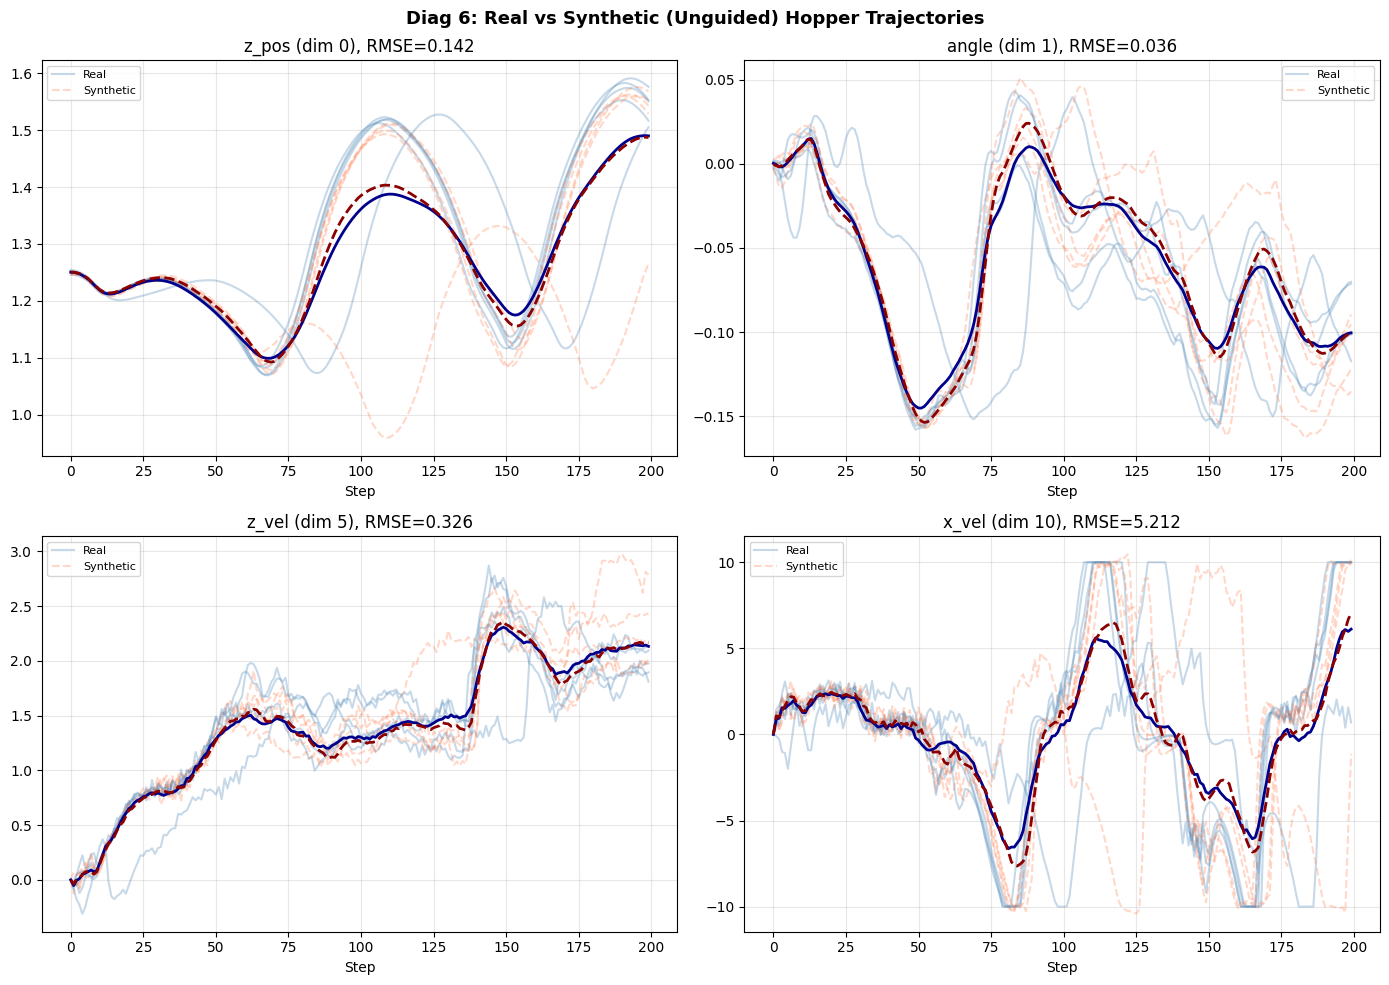

In [8]:
# ── Diagnostic 6: Trajectory Plots ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_dims = [0, 1, 5, 10]  # z_pos, angle, z_vel, x_vel
plot_names = ["z_pos", "angle", "z_vel", "x_vel"]

for idx, (d, dname) in enumerate(zip(plot_dims, plot_names)):
    ax = axes[idx // 2, idx % 2]
    for j in range(min(5, N_TRAJ)):
        ax.plot(real_trajs[j, :, d], color="steelblue", alpha=0.3, label="Real" if j == 0 else None)
        ax.plot(synth_states[j, :, d], color="coral", alpha=0.3, ls="--", label="Synthetic" if j == 0 else None)
    ax.plot(real_trajs[:, :, d].mean(0), color="darkblue", lw=2)
    ax.plot(synth_states[:, :, d].mean(0), color="darkred", lw=2, ls="--")
    ax.set_title(f"{dname} (dim {d}), RMSE={rmses[d]:.3f}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlabel("Step")

plt.suptitle("Diag 6: Real vs Synthetic (Unguided) Hopper Trajectories", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

v0.2.5.12: D4RL DIAGNOSTICS SUMMARY — Cross vs Within vs SAC Reference

Diagnostic                   Cross (6)    Within (6)  SAC ref (11)
─────────────────────────────────────────────────────────────────
1. Mean cosine sim              0.4688        0.7103        0.4737
   Min cosine                   0.2774        0.5151        0.2023
   Max cosine                   0.7783        0.9396        0.7734
2. |grad|/|act| ratio             18.4           6.6         572.7
3. GD convergence              +276.4%       +154.9%        -26.3%
5. NLL spread                     10.3           1.7          39.9
─────────────────────────────────────────────────────────────────


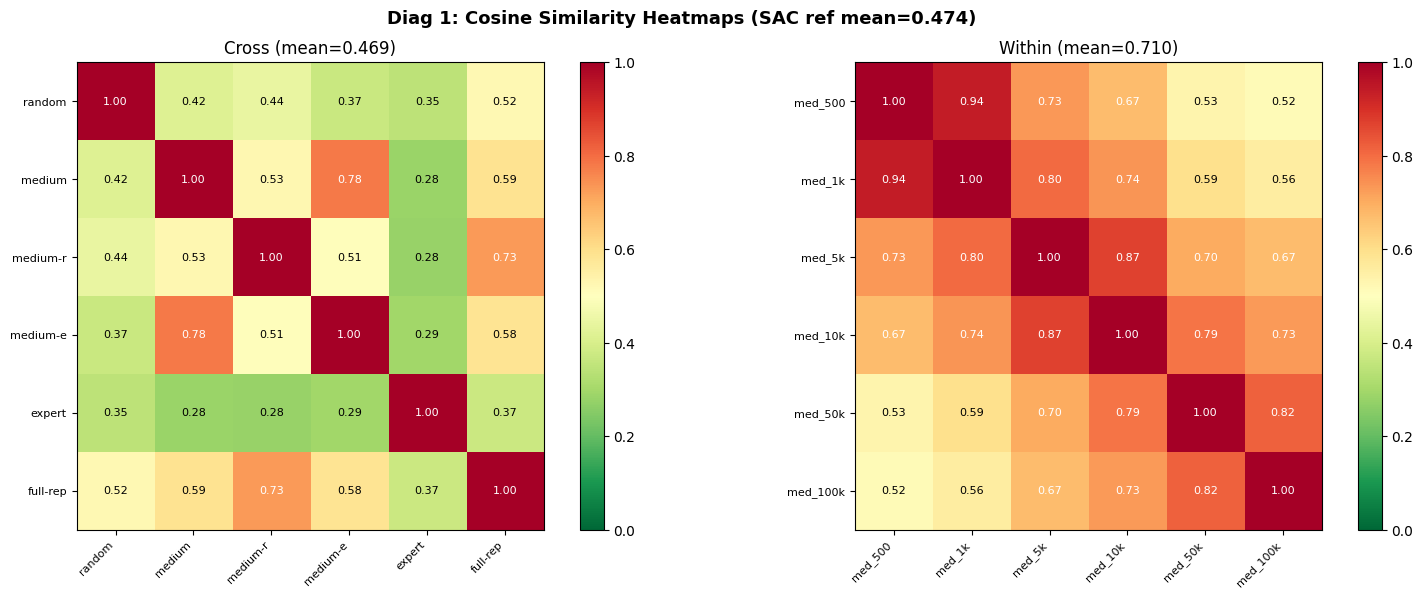

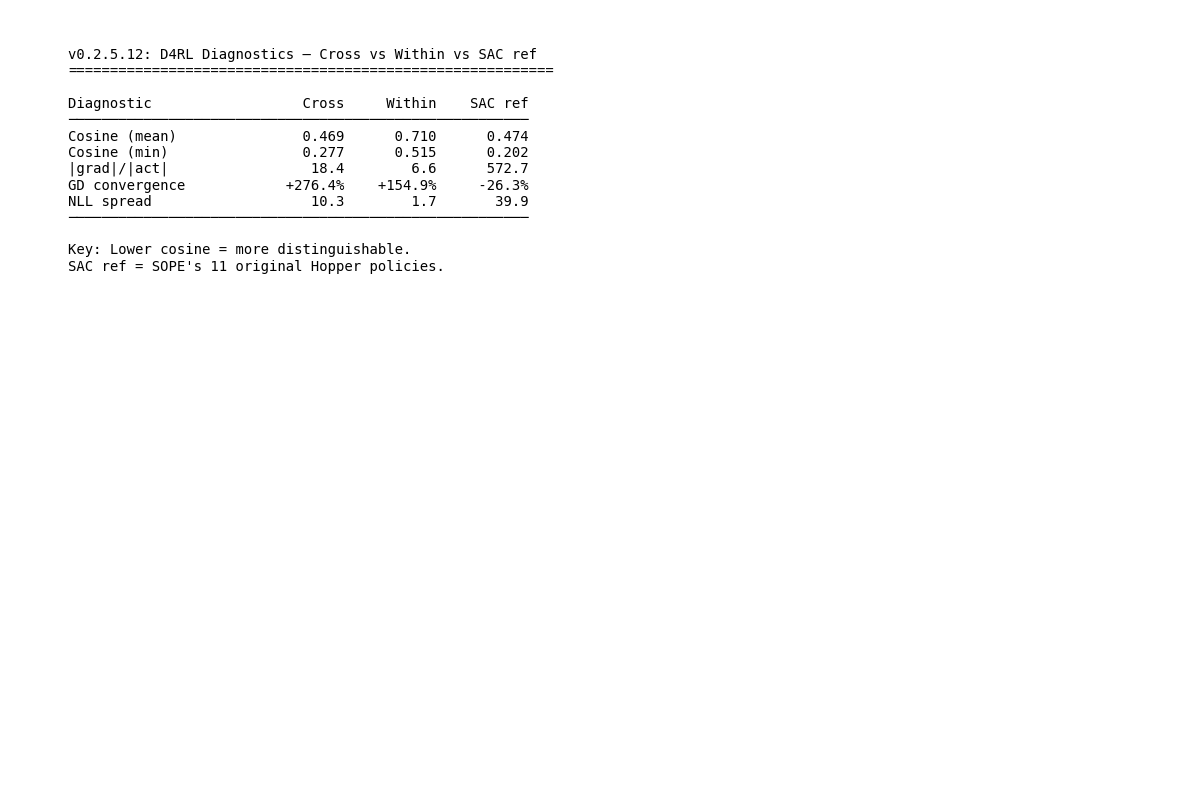

In [9]:
# ── Summary ──
print(f"{'='*80}")
print(f"v0.2.5.12: D4RL DIAGNOSTICS SUMMARY — Cross vs Within vs SAC Reference")
print(f"{'='*80}")

print(f"\n{'Diagnostic':<25} {'Cross (6)':>12} {'Within (6)':>13} {'SAC ref (11)':>13}")
print(f"{'─'*65}")
print(f"{'1. Mean cosine sim':<25} {cross_d1['mean']:>12.4f} {within_d1['mean']:>13.4f} {'0.4737':>13}")
print(f"{'   Min cosine':<25} {cross_d1['min']:>12.4f} {within_d1['min']:>13.4f} {'0.2023':>13}")
print(f"{'   Max cosine':<25} {cross_d1['max']:>12.4f} {within_d1['max']:>13.4f} {'0.7734':>13}")
print(f"{'2. |grad|/|act| ratio':<25} {cross_d2['mean']:>12.1f} {within_d2['mean']:>13.1f} {'572.7':>13}")
print(f"{'3. GD convergence':<25} {cross_d3['mean']:>+11.1f}% {within_d3['mean']:>+12.1f}% {'-26.3%':>13}")
print(f"{'5. NLL spread':<25} {cross_d5['spread']:>12.1f} {within_d5['spread']:>13.1f} {'39.9':>13}")
print(f"{'─'*65}")

# Cosine heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mat, nms, title in [
    (axes[0], cross_d1["cos_mat"], cross_names, f"Cross (mean={cross_d1['mean']:.3f})"),
    (axes[1], within_d1["cos_mat"], within_names, f"Within (mean={within_d1['mean']:.3f})"),
]:
    n = len(nms); short = [nm[:8] for nm in nms]
    im = ax.imshow(mat, cmap="RdYlGn_r", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(short, fontsize=8)
    for i in range(n):
        for j in range(n):
            c = "white" if mat[i,j] > 0.6 else "black"
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", color=c, fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
plt.suptitle("Diag 1: Cosine Similarity Heatmaps (SAC ref mean=0.474)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Summary figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.axis("off")
lines = [
    "v0.2.5.12: D4RL Diagnostics — Cross vs Within vs SAC ref",
    "=" * 58, "",
    f"{'Diagnostic':<22} {'Cross':>10} {'Within':>10} {'SAC ref':>10}",
    "─" * 55,
    f"{'Cosine (mean)':<22} {cross_d1['mean']:>10.3f} {within_d1['mean']:>10.3f} {'0.474':>10}",
    f"{'Cosine (min)':<22} {cross_d1['min']:>10.3f} {within_d1['min']:>10.3f} {'0.202':>10}",
    f"{'|grad|/|act|':<22} {cross_d2['mean']:>10.1f} {within_d2['mean']:>10.1f} {'572.7':>10}",
    f"{'GD convergence':<22} {cross_d3['mean']:>+9.1f}% {within_d3['mean']:>+9.1f}% {'-26.3%':>10}",
    f"{'NLL spread':<22} {cross_d5['spread']:>10.1f} {within_d5['spread']:>10.1f} {'39.9':>10}",
    "─" * 55, "",
    "Key: Lower cosine = more distinguishable.",
    "SAC ref = SOPE's 11 original Hopper policies.",
]
ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        fontsize=10, verticalalignment="top", fontfamily="monospace")
plt.tight_layout(); plt.show()